## Flow direction Analysis

In [1]:
import geopandas as gpd
import pandas as pd
import rasterio
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Path to data
diff_raster_path = "C:/Masterarbeit/Daten Masterarbeit/Datasets/Greenland/ArcticDEM/deg_difference/deg_difference100_python_Greenland.tif"

regions = {
    'SW': "C:/Masterarbeit/Daten Masterarbeit/Outputs/Moran_Approach2/Icethickness_ClusterMap_SW_1.0kmR.gpkg",
    'CW': "C:/Masterarbeit/Daten Masterarbeit/Outputs/Moran_Approach2/Icethickness_ClusterMap_CW_1.0kmR.gpkg",
    'NW': "C:/Masterarbeit/Daten Masterarbeit/Outputs/Moran_Approach2/Icethickness_ClusterMap_NW_1.0kmR.gpkg",
    'NO': "C:/Masterarbeit/Daten Masterarbeit/Outputs/Moran_Approach2/Icethickness_ClusterMap_NO_1.0kmR.gpkg",
    'NE': "C:/Masterarbeit/Daten Masterarbeit/Outputs/Moran_Approach2/Icethickness_ClusterMap_NE_1.0kmR.gpkg"
}

all_data = []

# Creation of loop
with rasterio.open(diff_raster_path) as src:
    for name, path in regions.items():
        print(f"Calculation Region: {name}...")
        
        # Loading of GeoPackage
        gdf = gpd.read_file(path)
        
        # Raster sampling and creation of new column
        coords = [(x, y) for x, y in zip(gdf.geometry.x, gdf.geometry.y)]
        gdf['angle_diff_deg'] = [x[0] for x in src.sample(coords)]
        
        # Filtering for NoData
        # Only values between 0 und 90 degrees
        gdf = gdf[(gdf['angle_diff_deg'] >= 0) & (gdf['angle_diff_deg'] <= 90)]
        
        # Ensure that nothing is overwritten
        df_temp = gdf[['angle_diff_deg', 'Cluster_Label']].copy()
        df_temp['Region'] = name
        
        all_data.append(df_temp)

# Total of all regions
df_total = pd.concat(all_data, ignore_index=True)

Calculation Region: SW...
Calculation Region: CW...
Calculation Region: NW...
Calculation Region: NO...
Calculation Region: NE...


C:\Users\Marco Karrer\AppData\Local\Temp\ipykernel_8916\3528300159.py:14: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.boxenplot(


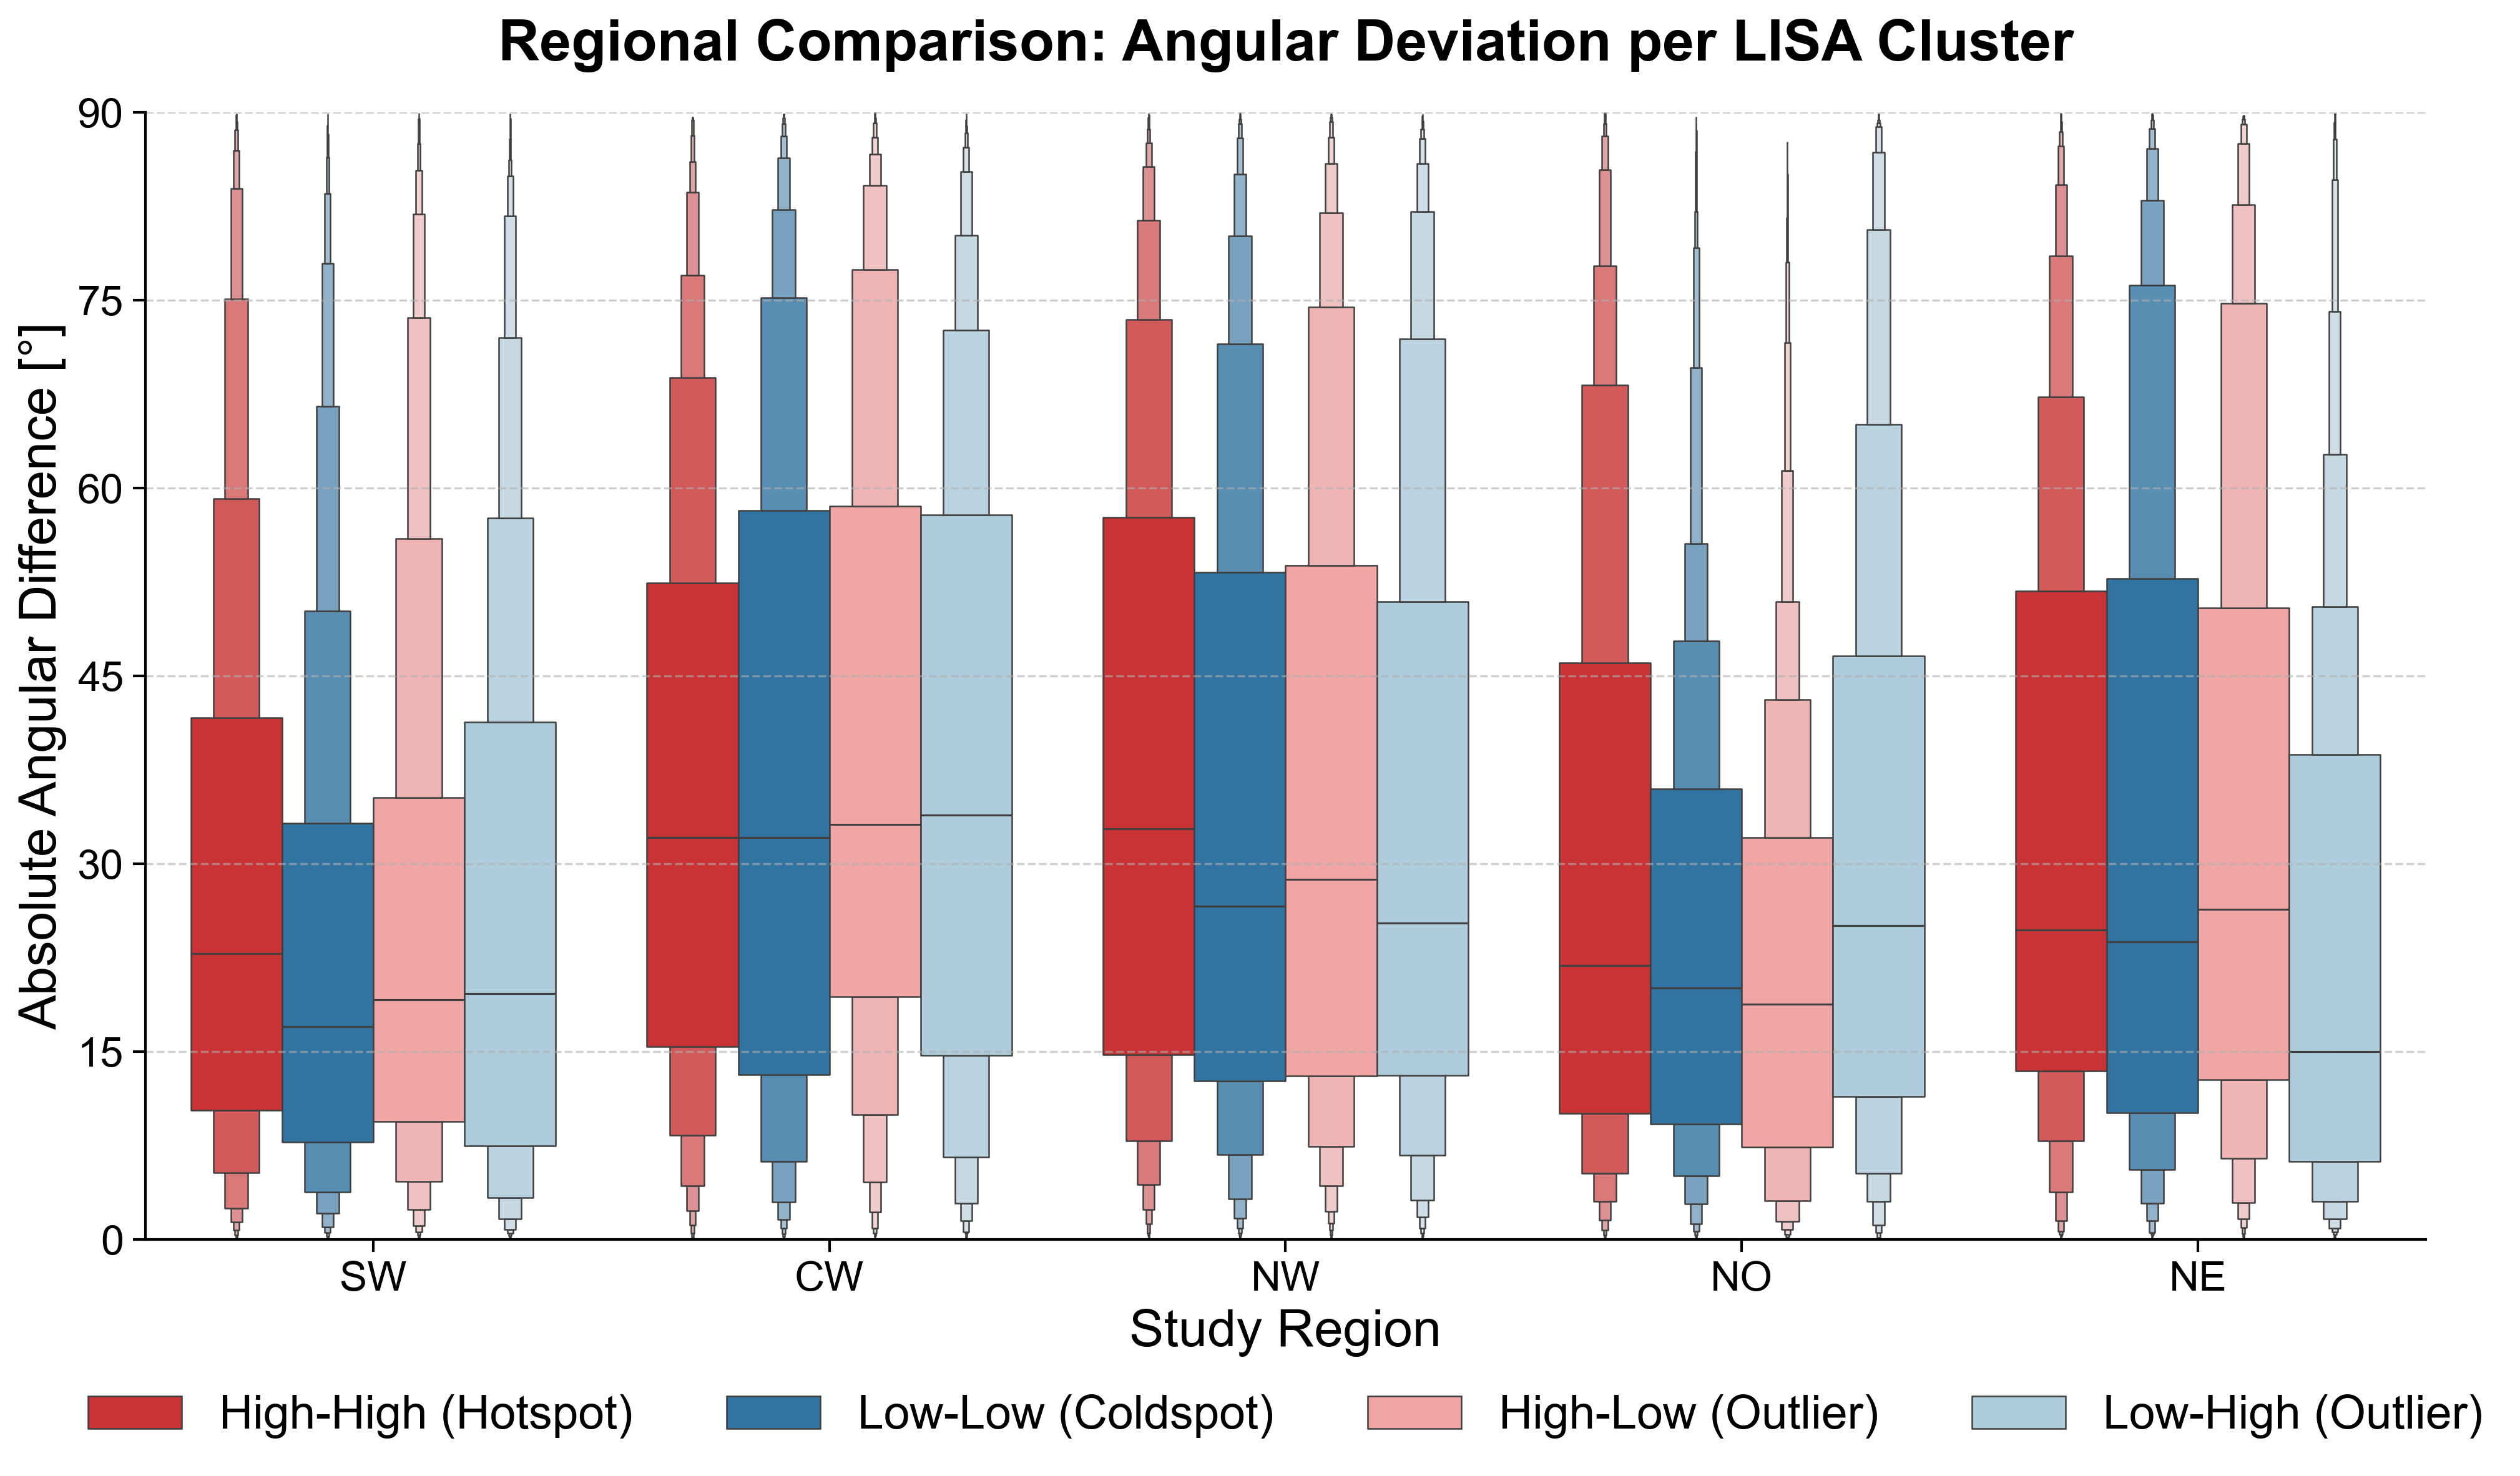


--- Median angular difference per region and cluster ---
Cluster_Label  High-High (Hotspot)  Low-Low (Coldspot)  High-Low (Outlier)  Low-High (Outlier)
Region                                                                                        
CW                       32.075348           32.114487           33.146698           33.898621
NE                       24.695999           23.774689           26.381042           14.974792
NO                       21.879913           20.067200           18.795349           25.085846
NW                       32.807724           26.592865           28.736740           25.271515
SW                       22.824493           16.975433           19.132294           19.632446


In [2]:
# Plotting style
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
sns.set_context("paper", font_scale=1.2)

# Clusters and colours
order = ["High-High (Hotspot)", "Low-Low (Coldspot)", "High-Low (Outlier)", "Low-High (Outlier)"]
lisa_colors = ['#e31a1c', '#1f78b4', '#fb9a99', '#a6cee3', '#d9d9d9']

# Plot creation
fig, ax = plt.subplots(figsize=(14, 8), dpi=300)

# Boxplot
sns.boxenplot(
    data=df_total, 
    x='Region', 
    y='angle_diff_deg', 
    hue='Cluster_Label', 
    hue_order=order,
    palette=lisa_colors,
    ax=ax,
    showfliers=False
)

# Axis and labelling
ax.set_title('Regional Comparison: Angular Deviation per LISA Cluster', fontsize=22, fontweight='bold', pad=20)
ax.set_ylabel('Absolute Angular Difference [°]', fontsize=20)
ax.set_xlabel('Study Region', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)

# Y-Axis fixation
ax.set_ylim(0, 90)
ax.set_yticks(np.arange(0, 91, 15))
ax.yaxis.grid(True, linestyle='--', alpha=0.6)

# Legend
ax.legend(
    title='', 
    loc='upper center', 
    bbox_to_anchor=(0.5, -0.10), 
    ncol=5, 
    frameon=False, 
    fontsize=18
)

# Layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
sns.despine()
plt.tight_layout()

# Saving
#plt.savefig("C:/Masterarbeit/Daten Masterarbeit/Outputs/Plots Deg Difference/Mann-Whitney U Test and Kolmogorov-Smirnov/Regional_Difference_Alignment", dpi=300, bbox_inches='tight')

plt.show()

# Statistics per cluster
print("\n--- Median angular difference per region and cluster ---")
median_table = df_total.groupby(['Region', 'Cluster_Label'])['angle_diff_deg'].median().unstack()
print(median_table[order].to_string())